In [7]:
 # -*- coding: utf-8 -*-
"""

Student ID: 4270173

"""

###
# The following adds the modules required for the code to run.
###
import numpy as np
import time
import matplotlib.pyplot as plt
import dlanalysis as dla
from mpl_toolkits.mplot3d import Axes3D
###
# This starts a timer. Used to calculate how long the code tool to run.
start_time=time.time()
# global sets the values "N" and "seed" to be recognisable across all classes.
global N, seed
# N is the number of particles the lattice will be made up of.
N = 1000
# seed is used to set the initial conditions in any random functions.
seed = 0

In [8]:
###############################################################################
'''
The following class creates a 3D lattice by generating a particle on a sphere
using randomly generated angles.
 It then sends this particle on a random walk until it comes in contact with
The initial particle is plotted at the centre, at which point it sticks to the
initial particle and becomes a part of the lattice.
 Another particle is then introduced and is given a random walk until it comes
in contact with the lattice, at which point that particle will stop and become
a part of the lattice.
 This process is repeated for the number N, defined in the previous section.
 Once all the particles have become a part of the lattice, the result is then
plotted, and the process is repeated for a 3D lattice in the next section.
'''

class walk3D():
    ###
    # __init__ is the initial function called in walk3D.
    # It calls the main functions to be used.
    ###
    def __init__(self,walk3D):
        self.walk3D = walk3D
        self.initialise()
        self.initwalk()
        self.WriteFile()
        self.analyse()
    ###
    # initialise only sets the initial radius of the circle.
    ###
    def initialise(self):
        # self.r is the radius of the circle.
        self.r = 1
        print('\n---------------------\n')
        print('Number of points=',N)
        print('\nSeed selected=',seed)

    ###
    # initwalk generates an array of points representing the locations of the
    # particles in the lattice.
    # It also calls the function used to increase the radius of the circle if
    # the particles
    # It then calls the function used to plot the lattice.
    ###
    def initwalk(self):
        # Creates an array of zeros to be replaced as the lattice is generated.
        self.randx = np.zeros(N)
        self.randy = np.zeros(N)
        self.randz = np.zeros(N)
        # Generates N random numbers uniformly between -1 and 1.
        temp_costhetas = np.random.uniform(1, -1, size=N)
        # Creates N random spherical coordinates.
        self.temp_thetas = np.arccos(temp_costhetas)
        self.temp_phis = np.random.uniform(-np.pi, np.pi, size=N)
        for self.i in range(N):
            # Converts the Spherical coordinates into Cartesian coordinates.
            tempx = self.r*np.sin(self.temp_thetas[self.i])\
                    *np.cos(self.temp_phis[self.i])
            tempy = self.r*np.sin(self.temp_thetas[self.i])\
                    *np.sin(self.temp_phis[self.i])
            tempz = self.r*np.cos(self.temp_thetas[self.i])
            # sends the particles on a random walk to create the lattice.
            self.randx[self.i], self.randy[self.i], self.randz[self.i]\
                        = self.walking(tempx,tempy,tempz)
            # resizes the sphere if the particles stick on the circumference.
            if self.randx[self.i]**2+self.randy[self.i]**2+\
                    self.randz[self.i]**2==self.r**2:
                self.newDist()
        # Generates a figure to illustrate the lattice in 3D.
        self.MyPlot()

    ###
    # walking loops a random walk until the generated particle touches the
    # existing lattice.
    # If the particle walks outside the surface of the sphere, the
    # particle is reintroduced at the other side of the sphere.
    ###
    def walking(self,x,y,z):
        mindist = self.r
        while True:
            # Exits the above while loop if the mindist becomes less than or equal to
            # to 1.
            if mindist<=1:
                break
            # moves the particle 1 up, down, left, right, forward or backwards.
            x = x + np.random.randint(-1,2)
            y = y + np.random.randint(-1,2)
            z = z + np.random.randint(-1,2)
            # calculates the x, y and z distances from the current particle to
            # all the lattice particles.
            diff = abs(self.randx-x),abs(self.randy-y),abs(self.randz-z)
            # Converts coordinates into squared distances.
            s= diff[0]**2+diff[1]**2+diff[2]**2
            # Finds the minimum of these distances.
            mindist = np.min(s)
            # Reintroduces the particle on the other side of the sphere if
            # it has wandered outside of the sphere's surface.
            if mindist>self.r**2:
                x = int(self.r*np.sin(-self.temp_thetas[self.i])
                        *np.cos(-self.temp_phis[self.i]))
                y = int(self.r*np.sin(-self.temp_thetas[self.i])
                        *np.sin(-self.temp_phis[self.i]))
                z = int(self.r*np.cos(-self.temp_thetas[self.i]))
        return x,y,z

    ###
    # newdist resizes the sphere so the lattice can grow to larger sizes than
    # the initial size.
    ###
    def newDist(self):
            # Finds all the particle distances from the centre of the sphere.
            ndist = self.randx**2+self.randy**2+self.randz**2
            # Takes the max value of these distances and adds a small number.
            maxdist = np.max(ndist)
            # sets this value to be the new radius of the sphere.
            self.r = np.sqrt(maxdist)+2e-16

    ###
    # MyPlot creates a figure window and generates the resultant lattice that
    # has been created on this figure.
    ###
    def MyPlot(self):
        # Creates the figure window.
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        # Names the X and Y axis
        plt.xlabel('x')
        plt.ylabel('y')
        # Creates a title for the figure.
        plt.title('DLA 3D')
        # Plots the X, Y and Z coordinates of the lattice particles.
        ax.scatter(self.randx, self.randy, self.randz,
                               c = self.randx**2+self.randy**2+self.randz**2,
                                              cmap=plt.cm.get_cmap('winter'))
        # Displays the radius of the sphere on the plot.
        ax.text(self.r/3.5,self.r/1.1,self.r/1.1,'Radius = %.2f'%self.r)
        # Saves the resultant figure into the same folder as the code.
        plt.savefig('DLA3D'+str(seed)+'_'+str(N)+'.png')
        end_time=time.time()
        # Shows how long the code took to run.
        print('\nElapsed time = ',repr(end_time-start_time))

    ###
    # WriteFile creates a Python file called DLA2D_data to be used for
    # analysis. Here, x and y represent the coordinates of the
    # particles in the lattice, and N is the number of particles.
    ###
    def WriteFile(self):
        # Creates a new file.
        f = open( 'DLA3D_data.py', 'w' )
        # Assigns x and y to lists.
        x = self.randx.tolist()
        y = self.randy.tolist()
        z = self.randz.tolist()
        # inputs x, y and N into the new file.
        f.write(str(N)+',['+str(self.r)+','+str(x) +','+ str(y)+','+ str(z))
        # closes the new file.
        f.close()

    def analyse(self):
        dla.DLAnalysis3D(self)

###############################################################################


---------------------

Number of points= 1000

Seed selected= 0


C:\Users\alexs\AppData\Local\Temp\ipykernel_23984\1123901302.py:133: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('winter'))



Elapsed time =  5.418497085571289

---------------------------

Data imported successfully for N = 1000

Radius of imported latice is r = 9

x points =[-5.43182235e-01 -8.63530617e-01 -5.64750117e-01 -1.00000000e+00
 -8.23886397e-01 -9.81112028e-01 -1.00000000e+00  0.00000000e+00
 -1.00000000e+00  2.21553296e-01  0.00000000e+00  2.35985188e-02
  0.00000000e+00  0.00000000e+00  0.00000000e+00  8.45541352e-02
 -1.00000000e+00  8.77102689e-01 -1.00000000e+00  0.00000000e+00
  1.00000000e+00 -2.68974349e-01 -1.00000000e+00 -1.04025204e+00
  0.00000000e+00 -1.00000000e+00 -5.64604976e-01  1.00000000e+00
  5.67816253e-01  8.18402669e-01 -1.69228931e+00  1.34994931e-01
  1.00000000e+00  2.00000000e+00  3.77363048e-01  0.00000000e+00
 -1.00000000e+00  1.54344022e+00 -1.00000000e+00 -4.50185183e-01
  1.29460291e+00 -1.70362465e+00  7.25778421e-01 -2.00000000e+00
  1.00000000e+00 -5.38406547e-01  1.68752078e+00  5.45974508e-01
  1.25981098e+00  3.34240196e-01  1.09797666e+00 -1.00000000e+00
  8

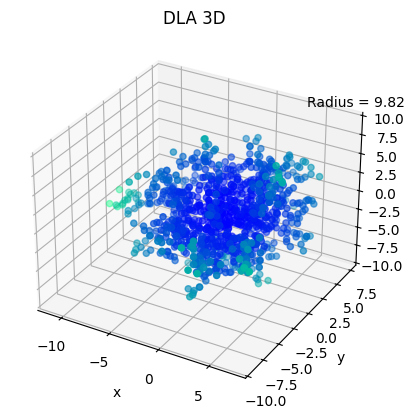

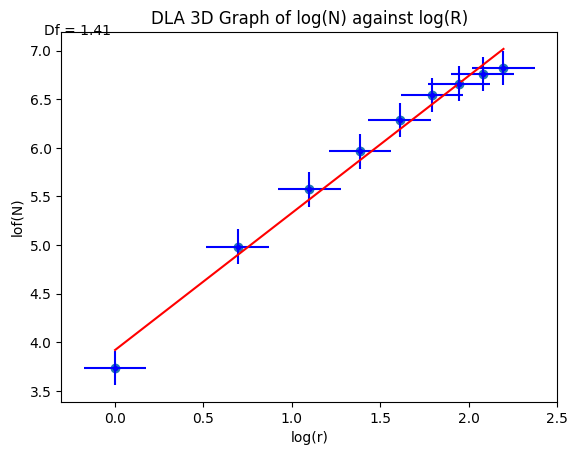

In [9]:
###
# This code will only run the main functions if the file is directly executed.
# It also allows the DLA module to be imported.
###
if __name__ == "__main__":
    # Generates a plot of a 3D lattice.
    walk3D(None)